## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [2]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___



- 엘보우 방법: 클러스터 개수 k에 따른 이너(샘플과 가장 가까운 센트로이드 사이의 평균 제곱 거리)를 그래프로 그린다. k가 증가할수록 이너셔는 감소하는데, 감소 폭이 급격히 줄어드는 지점(꺾이는 부분)을 최적의 k로 선택한다.
- 실루엣 점수: 각 샘플이 자신의 클러스터 내부 요소들과 얼마나 가깝고, 인접한 다른 클러스터와는 얼마나 먼지를 나타내는 지표이다. 실루엣 계수의 평균값이 가장 높거나, 모든 클러스터의 실루엣 계수가 고르게 높은 k를 선택한다.

### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___


- 대규모 확장 가능 알고리즘: 미니배치 K-평균, BIRCH
- 밀도 기반 알고리즘: DBSCAN, OPTICS

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___


가우시안 혼합이란 데이터가 여러 개의 가우시안 분포(정규 분포)의 혼합으로 생성되었다고 가정하는 확률이다. 군집화, 밀도 추정, 이상치 탐지 등에 사용된다.

### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [1]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\User\scikit_learn_data


####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_olivetti_faces

X = olivetti.data
y = olivetti.target

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, temp_idx = next(sss.split(X, y))

X_train, X_temp = X[train_idx], X[temp_idx]
y_train, y_temp = y[train_idx], y[temp_idx]

# 나머지 40%를 검증 세트와 테스트 세트로 절반씩 분리
sss_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(sss_val_test.split(X_temp, y_temp))

X_valid, X_test = X_temp[val_idx], X_temp[test_idx]
y_valid, y_test = y_temp[val_idx], y_temp[test_idx]

print(f"훈련 세트 크기: {X_train.shape}")
print(f"검증 세트 크기: {X_valid.shape}")
print(f"테스트 세트 크기: {X_test.shape}")

훈련 세트 크기: (240, 4096)
검증 세트 크기: (80, 4096)
테스트 세트 크기: (80, 4096)


####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

print(f"PCA 적용 후 피처 수: {X_train_pca.shape[1]}")

PCA 적용 후 피처 수: 177


####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

c:\Users\User\anaconda22\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=2 일 때 실루엣 점수: 0.1447


c:\Users\User\anaconda22\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=7 일 때 실루엣 점수: 0.0934


c:\Users\User\anaconda22\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

k=47 일 때 실루엣 점수: 0.1617


c:\Users\User\anaconda22\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=52 일 때 실루엣 점수: 0.1713


c:\Users\User\anaconda22\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=57 일 때 실루엣 점수: 0.1758


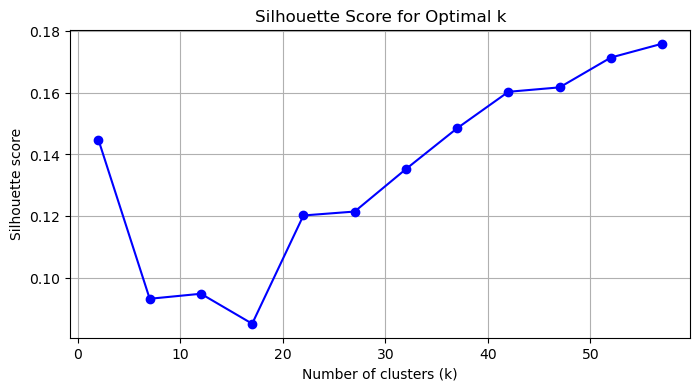


최적의 클러스터 개수: 57


c:\Users\User\anaconda22\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


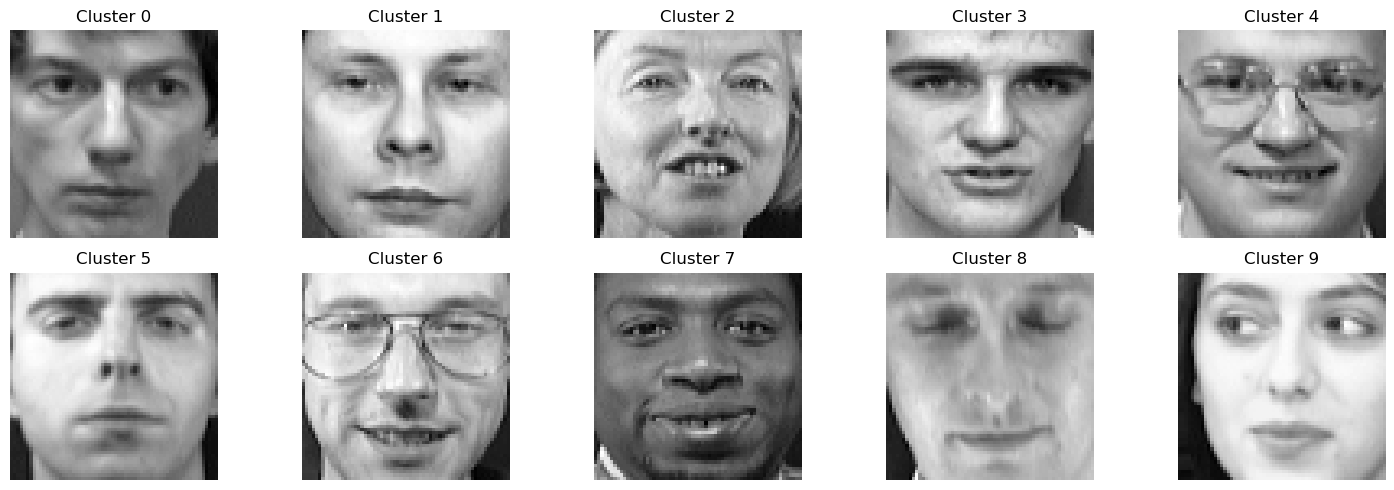

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. 다양한 k 값에 대해 실루엣 점수 계산
k_range = range(2, 60, 5) # 2부터 60까지 5씩 증가하며 확인
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    score = silhouette_score(X_train_pca, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={k} 일 때 실루엣 점수: {score:.4f}")

# 2. 실루엣 점수 그래프 시각화
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score for Optimal k")
plt.grid(True)
plt.show()

# 3. 최적의 k 선택 (점수가 가장 높은 지점)
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n최적의 클러스터 개수: {best_k}")

# 4. 최적의 k로 최종 군집화 수행
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
y_pred = kmeans_final.fit_predict(X_train_pca)

# 5. 군집 결과 시각화 (일부 예시)
# 각 클러스터의 첫 번째 이미지를 출력하여 어떤 얼굴들이 모였는지 확인합니다.
plt.figure(figsize=(15, 5))
for i in range(min(best_k, 10)): # 최대 10개 클러스터만 확인
    plt.subplot(2, 5, i + 1)
    # 해당 클러스터에 속한 첫 번째 이미지의 인덱스 찾기
    cluster_idx = np.where(y_pred == i)[0][0]
    plt.imshow(X_train[cluster_idx].reshape(64, 64), cmap="gray")
    plt.title(f"Cluster {i}")
    plt.axis("off")
plt.tight_layout()
plt.show()

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [9]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

--- Cluster 0 ---


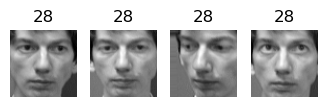

--- Cluster 1 ---


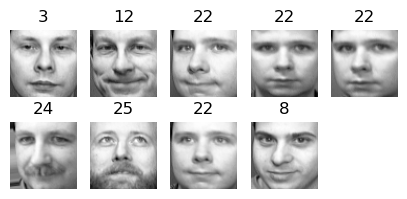

--- Cluster 2 ---


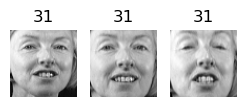

--- Cluster 3 ---


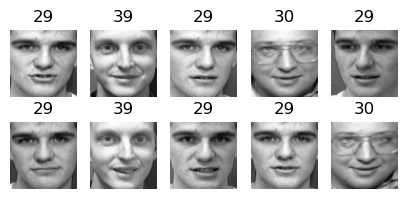

--- Cluster 4 ---


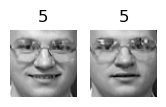

In [10]:
for cluster_id in range(5):
    print(f"--- Cluster {cluster_id} ---")
    
    # 현재 클러스터에 속한 데이터의 인덱스 찾기
    in_cluster = (y_pred == cluster_id)
    X_cluster = X_train[in_cluster]
    y_cluster = y_train[in_cluster] # 실제 사람이 누구인지 라벨 확인용
    
    # 해당 클러스터에 데이터가 있다면 시각화 (최대 10개까지만 표시)
    if len(X_cluster) > 0:
        plot_faces(X_cluster[:10], y_cluster[:10])
    else:
        print("이 클러스터에는 샘플이 없습니다.")